## Step 1: Connect to a SQLite Database

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")

conn = sqlite3.connect("ecommerce_advanced_sql.db")

In [2]:
cursor = conn.cursor()
cursor.execute("select name from sqlite_master where type= 'table';")

print(cursor.fetchall())

[('Customers',), ('Orders',), ('Products',), ('OrderDetails',)]


In [3]:
def view_table(table_name):
    query = f"SELECT * FROM {table_name}"
    df = pd.read_sql(query, conn)
    print(f"Table: {table_name}")
    print(df.head(5))
    print("\n")



view_table("Orders")
view_table("Products")
view_table("Customers")
view_table("OrderDetails")

Table: Orders
   OrderID  CustomerID   OrderDate  TotalAmount
0        1           1  2024-11-04       384.80
1        2           1  2025-04-12       788.85
2        3           1  2025-02-01      1669.87
3        4           2  2025-02-07      1102.12
4        5           2  2025-02-25       399.18


Table: Products
   ProductID                Name     Category   Price
0          1  Electronics Item 1  Electronics  140.14
1          2        Books Item 2  Electronics  297.44
2          3        Books Item 3         Toys   41.35
3          4     Clothing Item 4        Books  201.67
4          5         Toys Item 5         Toys  186.03


Table: Customers
   CustomerID              Name    Country
0           1     Anthony Cline  Australia
1           2     Breanna Booth     Canada
2           3    Jonathan Banks        USA
3           4      Connie Singh    Germany
4           5  Crystal Peterson        USA


Table: OrderDetails
   OrderDetailID  OrderID  ProductID  Quantity
0         

In [4]:
query = '''
select c.Name, c.Country, Sum(o.TotalAmount) as TotalSpent
from Customers c
join Orders o on c.CustomerID = o.CustomerID
group by c.Name, c.Country
having TotalSpent > 1000
order by TotalSpent desc
'''

df_top = pd.read_sql_query(query, conn)
display(df_top.head(10))


,Name,Country,TotalSpent
0,Connie Singh,Germany,5612.98
1,Elizabeth Wilson,USA,4586.69
2,Philip Welch,Canada,4566.69
3,Tracy Wheeler,Canada,4212.34
4,Breanna Booth,Canada,3977.93
5,Rachel Hall,Australia,3897.33
6,Miguel West,UK,3135.85
7,Anthony Cline,Australia,2843.52
8,Julie Johnson,USA,2779.24
9,Patrick Smith,Germany,2703.65


## 4. Visualize the top customers by total spending

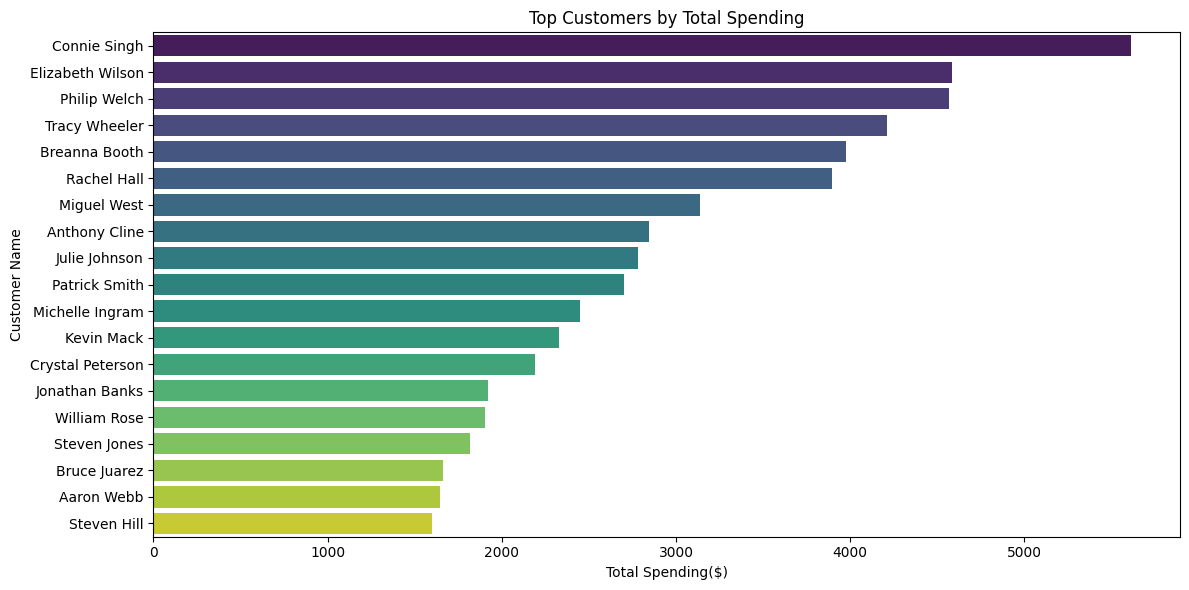

In [5]:
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(x='TotalSpent', y='Name', data=df_top, palette='viridis')
plt.title('Top Customers by Total Spending')
plt.xlabel('Total Spending($)')
plt.ylabel('Customer Name')
plt.tight_layout()
plt.show()

## Step 2: Products Not ordered in last 30 days

In [6]:
query = '''
select p.Name as ProductName, p.Category
from Products p
where p.ProductID not in (
select distinct od.ProductID
from OrderDetails od
join Orders o on od.OrderID = o.OrderID
where o.OrderDate >= date('now', '-30 days')
)
'''

df_not_ordered = pd.read_sql_query(query, conn)
display(df_not_ordered.head())


,ProductName,Category
0,Electronics Item 1,Electronics
1,Books Item 2,Electronics
2,Books Item 3,Toys
3,Books Item 7,Books
4,Toys Item 9,Toys


## Step 6: Monthly Revenue by Country

In [7]:
query = '''
select strftime('%Y-%m', o.OrderDate) as Month, c.Country, sum(o.TotalAmount) as TotalRevenue
from Orders o
join Customers c on o.CustomerID = c.CustomerID
where o.OrderDate >= date('now', '-1 year')
group by Month, c.Country
order by month
'''

df_monthly_revenue = pd.read_sql_query(query, conn)
display(df_monthly_revenue.head(10))

,Month,Country,TotalRevenue
0,2024-10,Australia,1751.30
1,2024-10,USA,2200.88
2,2024-11,Australia,466.82
3,2024-11,Canada,3707.61
4,2024-11,Germany,2840.40
5,2024-11,USA,2548.23
6,2024-12,Australia,671.56
7,2024-12,Canada,284.17
8,2024-12,Germany,2926.71
9,2024-12,USA,275.76


Step 7: Visualize Monthly Revenue by Country

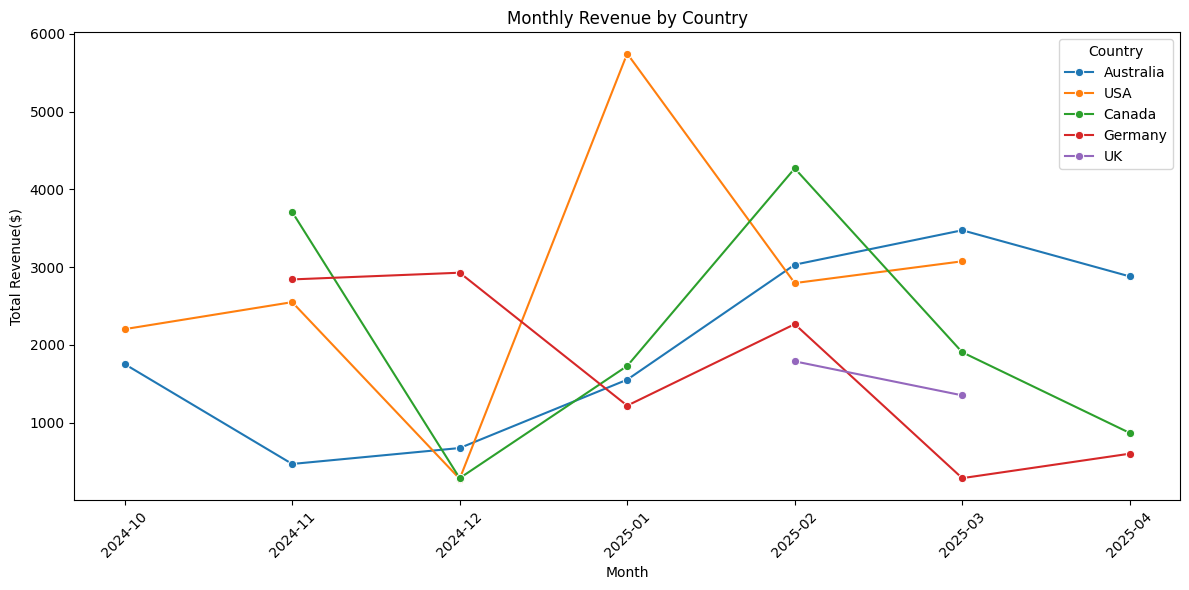

In [9]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_monthly_revenue, x='Month', y='TotalRevenue', hue='Country', marker='o')
plt.title('Monthly Revenue by Country')
plt.xlabel('Month')
plt.ylabel('Total Revenue($)')
plt.xticks(rotation=45)
plt.legend(title='Country')
plt.tight_layout()
plt.show()

step 8: Subqury to find highest ordered product

In [17]:
query = '''
select c.Name, o.OrderDate, o.TotalAmount
from Orders o
join Customers c on o.CustomerID = c.CustomerID
where o.TotalAmount = (
select max(TotalAmount) from Orders
)
'''

df_highest_order = pd.read_sql_query(query, conn)
display(df_highest_order.head(10))

,Name,OrderDate,TotalAmount
0,Connie Singh,2025-02-08,2265.25


In [18]:
# Step 9: Visualize the highest ordered product

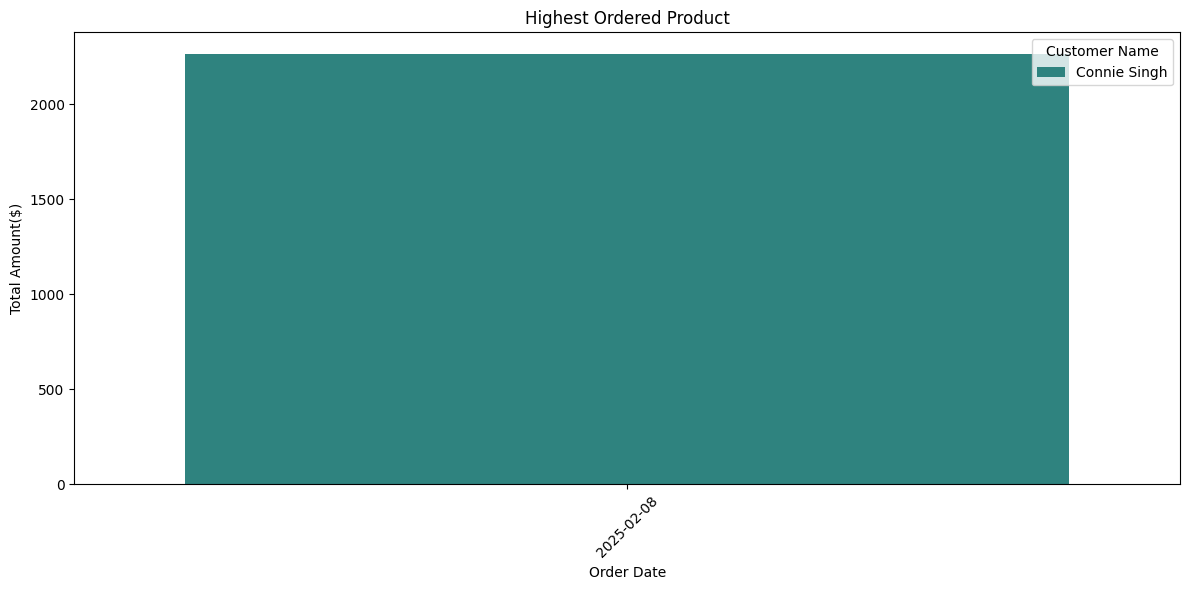

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_highest_order, x='OrderDate', y='TotalAmount', hue='Name', palette='viridis')
plt.title('Highest Ordered Product')
plt.xlabel('Order Date')
plt.ylabel('Total Amount($)')
plt.xticks(rotation=45)
plt.legend(title='Customer Name')
plt.tight_layout()
plt.show()

In [24]:

## Step 10: Closed connection

In [25]:
conn.close()